1. EDA и очистка. Изучи датасет players.csv. Распределение рыночных стоимостей — нормальное ли оно? Есть ли выбросы среди стоимостей?
2. Анализ по позициям. Кто стоит дороже — нападающие, защитники или вратари? Визуализируй через boxplot в seaborn. НОВОЕ
3. Возраст и стоимость. Как рыночная стоимость меняется с возрастом? Найди пик карьеры. Используй scatter plot с trend line в seaborn. НОВОЕ
4. Проверка гипотезы. Правда ли что нападающие стоят статистически значимо дороже защитников? Выбери правильный тест и обоснуй выбор.
5. Линейная регрессия. Построй простую модель: предсказывай рыночную стоимость через возраст. Интерпретируй коэффициенты. НОВОЕ
6. Интерактивный график. Scatter plot в plotly: возраст vs стоимость, с именами игроков при наведении. НОВОЕ
7. Рекомендации. 3-5 инсайтов для спортивного директора в Markdown — на что смотреть при поиске недооценённых игроков.

# 1. EDA и разведка.

In [1]:
import pandas as pd
import seaborn as sns
import scipy.stats as stats

In [2]:
df = pd.read_csv('C:/Users/user/OneDrive/Рабочий стол/datasets/Transfermarkt/players.csv')
df.head(10)

,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,agent_name,image_url,international_caps,international_goals,current_national_team_id,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
0,10,Miroslav,Klose,Miroslav Klose,2015,398,miroslav-klose,Poland,Opole,Germany,...,ASBW Sport Marketing,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/miroslav-klose...,IT1,Società Sportiva Lazio S.p.A.,1000000.0,30000000.0
1,26,Roman,Weidenfeller,Roman Weidenfeller,2017,16,roman-weidenfeller,Germany,Diez,Germany,...,Neubauer 13 GmbH,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/roman-weidenfe...,L1,Borussia Dortmund,750000.0,8000000.0
2,65,Dimitar,Berbatov,Dimitar Berbatov,2015,1091,dimitar-berbatov,Bulgaria,Blagoevgrad,Bulgaria,...,CSKA-AS-23 Ltd.,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/dimitar-berbat...,GR1,Panthessalonikios Athlitikos Omilos Konstantin...,1000000.0,34500000.0
3,77,NaN,Lúcio,Lúcio,2012,506,lucio,Brazil,Brasília,Brazil,...,NaN,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/lucio/profil/s...,IT1,Juventus Football Club,200000.0,24500000.0
4,80,Tom,Starke,Tom Starke,2017,27,tom-starke,East Germany (GDR),Freital,Germany,...,IFM,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/tom-starke/pro...,L1,FC Bayern München,100000.0,3000000.0
5,109,NaN,Dedê,Dedê,2013,825,dede,Brazil,Belo Horizonte,Brazil,...,Football Concept,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/dede/profil/sp...,TR1,Eskisehirspor,400000.0,9500000.0
6,123,Christoph,Metzelder,Christoph Metzelder,2012,33,christoph-metzelder,Germany,Haltern,Germany,...,NaN,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/christoph-metz...,L1,FC Schalke 04,1500000.0,9500000.0
7,132,Tomas,Rosicky,Tomas Rosicky,2015,11,tomas-rosicky,CSSR,Praha,Czech Republic,...,NaN,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/tomas-rosicky/...,GB1,Arsenal Football Club,350000.0,17500000.0
8,162,Marc,Ziegler,Marc Ziegler,2012,79,marc-ziegler,Germany,Blieskastel,Germany,...,NaN,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/marc-ziegler/p...,L1,Verein für Bewegungsspiele Stuttgart 1893,200000.0,1250000.0
9,215,Roque,Santa Cruz,Roque Santa Cruz,2015,1084,roque-santa-cruz,Paraguay,Asunción,Paraguay,...,NaN,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/roque-santa-cr...,ES1,Málaga CF,250000.0,12000000.0


In [3]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47716 entries, 0 to 47715
Data columns (total 26 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   player_id                             47716 non-null  int64  
 1   first_name                            44621 non-null  object 
 2   last_name                             47716 non-null  object 
 3   name                                  47716 non-null  object 
 4   last_season                           47716 non-null  int64  
 5   current_club_id                       47716 non-null  int64  
 6   player_code                           47716 non-null  object 
 7   country_of_birth                      42551 non-null  object 
 8   city_of_birth                         42827 non-null  object 
 9   country_of_citizenship                47443 non-null  object 
 10  date_of_birth                         47667 non-null  object 
 11  sub_position   

player_id                                   0
first_name                               3095
last_name                                   0
name                                        0
last_season                                 0
current_club_id                             0
player_code                                 0
country_of_birth                         5165
city_of_birth                            4889
country_of_citizenship                    273
date_of_birth                              49
sub_position                              457
position                                    0
foot                                     5090
height_in_cm                             3653
contract_expiration_date                16365
agent_name                              22037
image_url                                   0
international_caps                      30098
international_goals                     30098
current_national_team_id                45262
url                               

In [4]:
df.describe()

,player_id,last_season,current_club_id,height_in_cm,international_caps,international_goals,current_national_team_id,market_value_in_eur,highest_market_value_in_eur
count,4.771600e+04,47716.000000,47716.000000,44063.000000,17618.000000,17618.000000,2454.000000,3.150700e+04,3.150700e+04
mean,4.876292e+05,2021.452678,8087.536571,182.019903,11.299693,1.183733,8622.955583,1.612128e+06,3.836841e+06
std,3.713582e+05,4.263613,16651.740647,7.415497,18.901873,4.126926,6461.846560,6.404922e+06,1.003214e+07
min,1.000000e+01,2012.000000,2.000000,17.000000,0.000000,0.000000,3300.000000,1.000000e+04,1.000000e+04
25%,1.769338e+05,2018.000000,504.000000,177.000000,1.000000,0.000000,3587.000000,1.000000e+05,2.750000e+05
50%,4.019190e+05,2024.000000,1464.500000,182.000000,4.000000,0.000000,5674.000000,2.500000e+05,8.000000e+05
75%,7.308642e+05,2025.000000,6643.000000,187.000000,12.000000,1.000000,13975.000000,7.000000e+05,3.000000e+06
max,1.545443e+06,2025.000000,138189.000000,210.000000,228.000000,143.000000,53982.000000,2.000000e+08,2.000000e+08


In [5]:
# Проверяю максимальные цены на рынке на выброс.
df.nlargest(5,'market_value_in_eur')[['name','market_value_in_eur']]

,name,market_value_in_eur
24502,Erling Haaland,200000000.0
20806,Kylian Mbappé,180000000.0
22365,Vinicius Junior,180000000.0
30532,Jude Bellingham,160000000.0
24077,Phil Foden,150000000.0


In [6]:
# Убираю из датасета игроков без рыночной стоиомости
df_clean = df.dropna(subset=['market_value_in_eur']).copy()
print(f'Осталось игроков: {len(df_clean)}')

Осталось игроков: 31507


# 2. Анализ по позициям.
Строим плот зависимости цены на рынке от позиции.

<Axes: xlabel='position', ylabel='market_value_in_eur'>

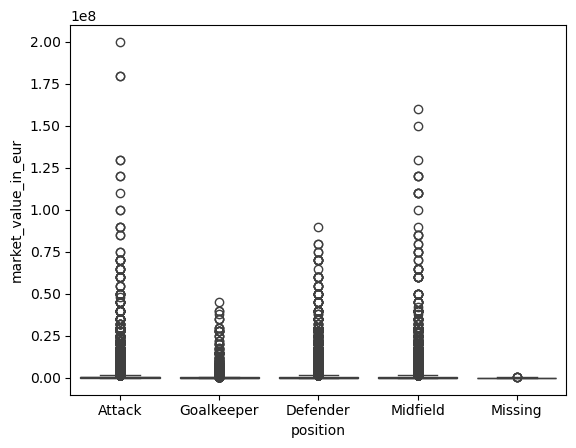

In [7]:
import seaborn as sns
sns.boxplot(data=df_clean, x='position', y='market_value_in_eur')

Text(0.5, 1.0, 'Стоимость от позиции')

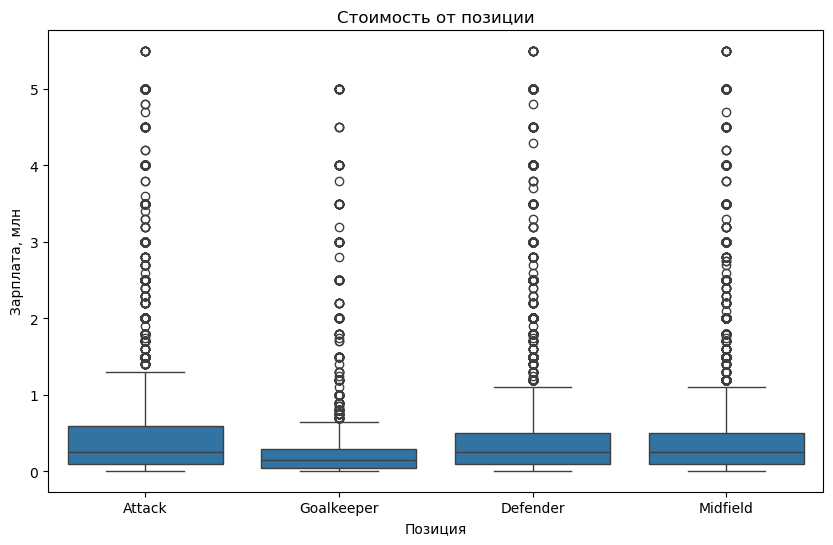

In [8]:
# Улучшаем график, чистим данные
import matplotlib.pyplot as plt
df_clean['market_value_m'] = df_clean['market_value_in_eur'] / 1_000_000
df_clean = df_clean[df_clean['position'] != 'Missing']
threshold = df_clean['market_value_m'].quantile(0.95)
df_viz = df_clean[df_clean['market_value_m'] < threshold]
plt.figure(figsize=(10,6))
sns.boxplot(data=df_viz, x='position', y='market_value_m')
plt.xlabel('Позиция')
plt.ylabel('Зарплата, млн')
plt.title('Стоимость от позиции')

Инсайты для директора:
1. Позиция вратаря заметно дешевле на трансферном рынке.
2. Остальные позиции (кроме вратарской) не влияют на стоимость игрока на рынке.
3. Стомость нападающих начинается дороже относительно других позиций.

# 3. Проверяем, меняется ли рыночная стоимость с возрастом.

In [9]:
# Cчитаем возраст игроков
df_clean['date_of_birth'] = pd.to_datetime(df_clean['date_of_birth'])
df_clean['age'] = (pd.Timestamp.now() - df_clean['date_of_birth']).dt.days / 365
df_clean['age'].head()

0    48.073973
1    45.912329
2    45.427397
3    48.161644
4    45.298630
Name: age, dtype: float64

In [10]:
print(df_clean['age'].describe())

count    31375.000000
mean        31.594545
std          6.647349
min         16.876712
25%         26.394521
50%         31.065753
75%         36.115068
max         56.471233
Name: age, dtype: float64


In [11]:
# Средний возраст слишком высокий. Возможно это тренеры или функционеры, либо информы. Для анализа они не релевантны.
df_clean = df_clean[(df_clean['age'] >= 16) & (df_clean['age'] <= 40)]
df_clean['age'].describe()

count    27483.000000
mean        29.918697
std          5.175103
min         16.876712
25%         25.805479
50%         29.904110
75%         33.972603
max         40.000000
Name: age, dtype: float64

<Axes: xlabel='age', ylabel='market_value_m'>

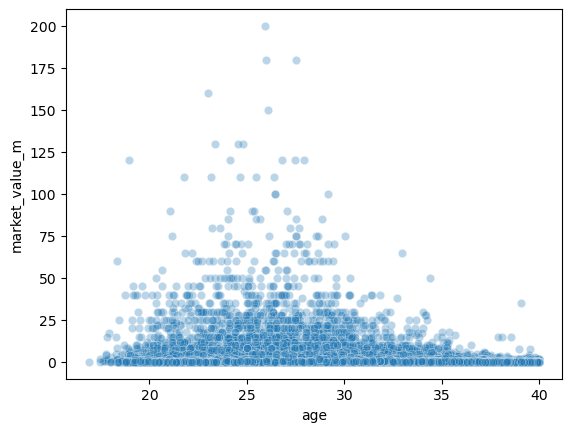

In [12]:
sns.scatterplot(data=df_clean, x='age', y='market_value_m', alpha=0.3)

<Axes: xlabel='age', ylabel='market_value_m'>

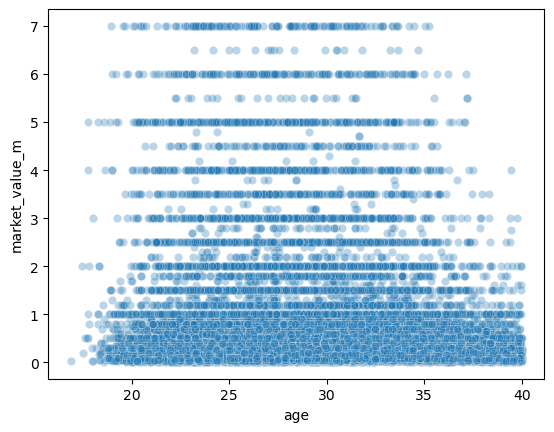

In [13]:
threshold = df_clean['market_value_m'].quantile(0.95)
df_viz = df_clean[df_clean['market_value_m'] < threshold]
sns.scatterplot(data=df_viz, x='age', y='market_value_m', alpha=0.3)

<Axes: xlabel='age', ylabel='market_value_m'>

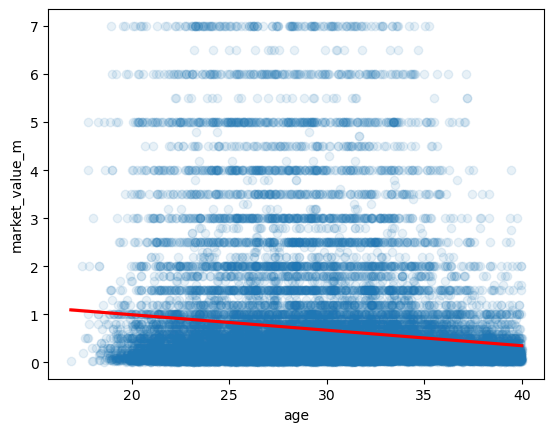

In [14]:
sns.regplot(data=df_viz, x='age', y='market_value_m', 
            scatter_kws={'alpha':0.1}, line_kws={'color':'red'})

<Axes: title={'center': 'Median value on age'}, xlabel='age'>

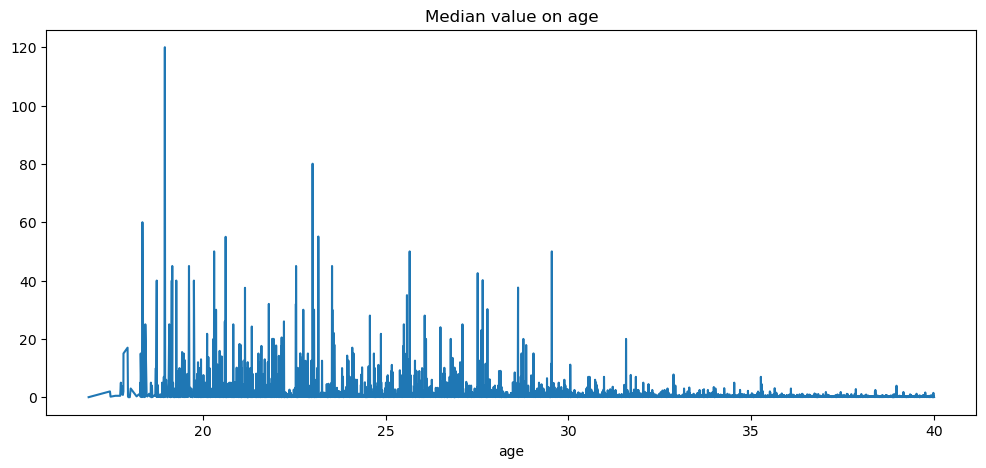

In [15]:
age_value = df_clean.groupby('age')['market_value_m'].median()
age_value.plot(figsize=(12,5), title='Median value on age')

<Axes: title={'center': 'Медианная стоимость по возрасту'}, xlabel='age_group'>

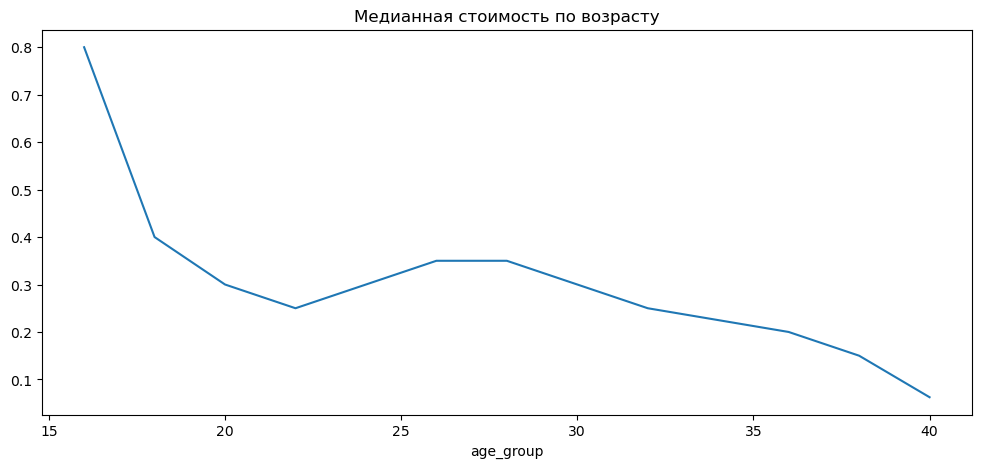

In [16]:
df_clean['age_group'] = (df_clean['age'] // 2) * 2
age_value = df_clean.groupby('age_group')['market_value_m'].median()
age_value.plot(figsize=(12,5), title='Медианная стоимость по возрасту')

Инсайт для директора.
В целом наблюдается яркая трендовая линия по отношению к  возрасту и стоимости игрока. но нельзя об этом говорить однозначно, так как выборка игроков младшего возраста (16-17 лет) не дает полной картины. Данные говорят о том, что игроки в младшем возрасте (до 20 лет) могут стоит дешевле своей рыночной стоимости, поэтому стоит обращать на них больше внимания при отборе.

# 4. Проверка гипотезы. Правда ли что нападающие стоят статистически значимо дороже вратарей?

H0 - Позиция игрока не влияет на его рыночную стоимость.

Н1 - Позиция игрока влияет на его рыночную стоимость

Проведем тест Манн-Уитника (U-test)для двух непараметрических параметров для проверки p-value нашей гипотезы.

In [17]:
attack = df_clean[df_clean['position'] == 'Attack']['market_value_m']
goalkeeper = df_clean[df_clean['position'] == 'Goalkeeper']['market_value_m']
stats.mannwhitneyu(x=attack, y=goalkeeper, alternative = 'two-sided')

MannwhitneyuResult(statistic=np.float64(14432029.5), pvalue=np.float64(1.2852164797615903e-99))

P-value < 0.05, отвергаем Н0, результат стат. значимый

Инсайт 4. Вратари статистически дешевле нападающих — 
возможность сэкономить бюджет. Однако клубу нужен только один основной 
вратарь, поэтому общая экономия ограничена. 

# 5. Линейная регрессия. Построй простую модель: предсказывай рыночную стоимость через возраст. Интерпретируй коэффициенты.



In [18]:
from sklearn.linear_model import LinearRegression
age = df_clean[['age']]
value = df_clean[['market_value_m']]
model = LinearRegression()
model.fit(age.values, value)
print("coef:", model.coef_[0])
print("intercept:", model.intercept_)

pred = model.predict([[10]])
print("prediction for x=10:", pred[0])

coef: [-0.19167193]
intercept: [7.54168091]
prediction for x=10: [5.62496161]


Инсайт 5. Результаты говорят нам об обратной взаимосвязи возраста игрока и его стоимости на рынке (коэф.: -0.019163287), то есть с каждым годом игрок теряет 192 тысячи от своей стоимости.

# 6. Рисуем интерактивный график.

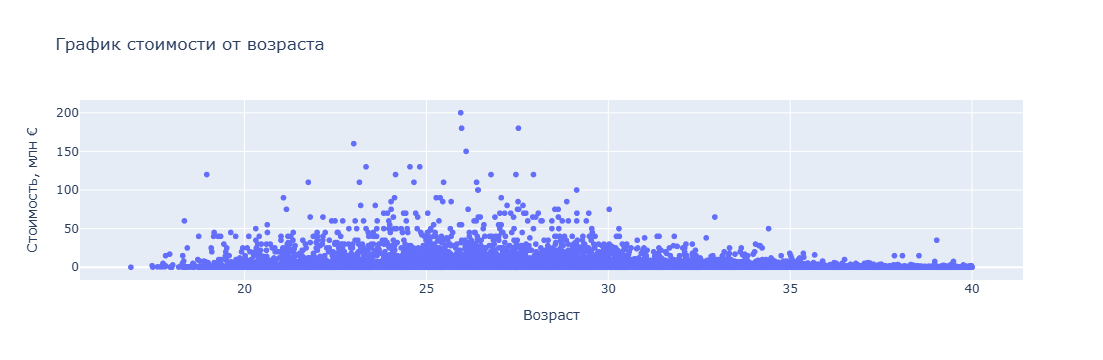

In [28]:
import plotly.express as px
fig = px.scatter(data_frame = df_clean, 
                 hover_name = 'name',
                 x='age', 
                 y='market_value_m', 
                 labels={'age': 'Возраст', 'market_value_m': 'Стоимость, млн €'},
                 title='График стоимости от возраста'
                )
fig.show()

Инсайты для спортивного директора.
1. Позиция вратаря заметно дешевле на трансферном рынке.
2. Остальные позиции (кроме вратарской) не влияют на стоимость игрока на рынке.
3. Стомость нападающих начинается дороже относительно других позиций.
4. Данные говорят о том, что игроки в младшем возрасте (до 20 лет) могут стоит дешевле своей рыночной стоимости, поэтому стоит обращать на них больше внимания при отборе.
5. Результаты говорят нам об обратной взаимосвязи возраста игрока и его стоимости на рынке (коэф.: -0.019163287), то есть с каждым годом игрок теряет 192 тысячи от своей стоимости.